### Text Classification with Pretrained Model of Confusion Matrix or Prediction

In [3]:
#import opendatasets as od
#od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")


In [4]:
import torch
import random
import glob
from torch import nn
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
import torchvision.transforms as transforms
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from PIL import Image
import torchvision

In [18]:
import pandas as pd
def load_csv(path):
    return pd.read_csv(path)
def combine_data(dfs):
    return pd.concat(dfs, ignore_index=True)
def add_image_path(df, folder_path):
    # Ensure paths are constructed correctly
    df["image:FILE"] = df["image:FILE"].apply(lambda x: os.path.join(folder_path, x))
    return df
train = load_csv("/home/dell/Desktop/project /archive(1)/train.csv")
val = load_csv("/home/dell/Desktop/project /archive(1)/val.csv")
data_df = combine_data([train, val])
data_df = add_image_path(data_df, "/home/dell/Desktop/project /archive(1)/")
print("Data shape:", data_df.shape)
data_df.head()


Data shape: (1167, 2)


,image:FILE,category
0,/home/dell/Desktop/project /archive(1)/train/h...,0
1,/home/dell/Desktop/project /archive(1)/train/h...,0
2,/home/dell/Desktop/project /archive(1)/train/h...,0
3,/home/dell/Desktop/project /archive(1)/train/h...,0
4,/home/dell/Desktop/project /archive(1)/train/h...,0


In [19]:
print("Classes are: ")
print(data_df["category"].unique())
print()
print("Classes ditrubution are: ")
print(data_df["category"].value_counts())

Classes are: 
[0 1 2]

Classes ditrubution are: 
category
2    393
1    389
0    385
Name: count, dtype: int64


In [20]:
train = data_df.sample(frac=0.7, random_state=7)
test = data_df.drop(train.index)

In [21]:
# Training Transform with Augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Testing Transform (NO Augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [22]:
label_encoder = LabelEncoder()

class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        self.labels = torch.tensor(
            label_encoder.fit_transform(dataframe["category"])
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx, 0]
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [23]:
train_dataset = CustomImageDataset(train, train_transform)
test_dataset = CustomImageDataset(test, test_transform)

BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
googlenet_model = models.googlenet(weights="DEFAULT")

# Replace final layer for 3 classes
num_classes = len(data_df["category"].unique())
googlenet_model.fc = nn.Linear(1024, num_classes)

googlenet_model = googlenet_model.to(device)

In [25]:
for param in googlenet_model.parameters():
    param.requires_grad = False

# Unfreeze final layer
for param in googlenet_model.fc.parameters():
    param.requires_grad = True


In [26]:
LR = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = Adam(filter(lambda p: p.requires_grad, googlenet_model.parameters()),
                 lr=LR, weight_decay=1e-4)

from torch.optim.lr_scheduler import StepLR
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

In [27]:
def train_model(model, loader, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0

        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        scheduler.step()
        acc = correct / len(train_dataset) * 100
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.3f} | Acc: {acc:.2f}%")


In [28]:
print("\n Stage 1: Training FC Layer Only\n")
train_model(googlenet_model, train_loader, epochs=10)


 Stage 1: Training FC Layer Only

Epoch 1/10 | Loss: 92.245 | Acc: 57.77%
Epoch 2/10 | Loss: 71.062 | Acc: 72.83%
Epoch 3/10 | Loss: 65.667 | Acc: 75.40%
Epoch 4/10 | Loss: 55.089 | Acc: 80.17%
Epoch 5/10 | Loss: 56.639 | Acc: 77.97%
Epoch 6/10 | Loss: 53.378 | Acc: 79.44%
Epoch 7/10 | Loss: 48.732 | Acc: 82.01%
Epoch 8/10 | Loss: 51.878 | Acc: 81.76%
Epoch 9/10 | Loss: 51.313 | Acc: 79.68%
Epoch 10/10 | Loss: 50.761 | Acc: 82.50%


In [ ]:
for name, param in googlenet_model.named_parameters():
    if ("inception4" in name) or ("inception5" in name):
        param.requires_grad = True

optimizer = Adam(filter(lambda p: p.requires_grad, googlenet_model.parameters()),
                 lr=1e-4, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

print("\n Stage 2: Fine-Tuning Last Inception Blocks\n")
train_model(googlenet_model, train_loader, epochs=10)


 Stage 2: Fine-Tuning Last Inception Blocks

Epoch 1/10 | Loss: 37.942 | Acc: 85.80%
Epoch 2/10 | Loss: 24.571 | Acc: 91.80%
Epoch 3/10 | Loss: 19.570 | Acc: 93.27%
Epoch 4/10 | Loss: 14.846 | Acc: 95.47%
Epoch 5/10 | Loss: 13.696 | Acc: 95.84%
Epoch 6/10 | Loss: 11.223 | Acc: 96.08%
Epoch 7/10 | Loss: 10.160 | Acc: 96.08%
Epoch 8/10 | Loss: 9.786 | Acc: 97.06%
Epoch 9/10 | Loss: 9.202 | Acc: 97.43%
Epoch 10/10 | Loss: 10.313 | Acc: 96.82%


In [ ]:
googlenet_model.eval()
correct = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = googlenet_model(imgs)
        correct += (outputs.argmax(1) == labels).sum().item()

acc = correct / len(test_dataset) * 100
print("\n FINAL TEST ACCURACY:", round(acc, 2), "%")



 FINAL TEST ACCURACY: 95.14 %


### Confusion Matrix

In [ ]:
def plot_confusion_matrix(model, loader, class_names):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()


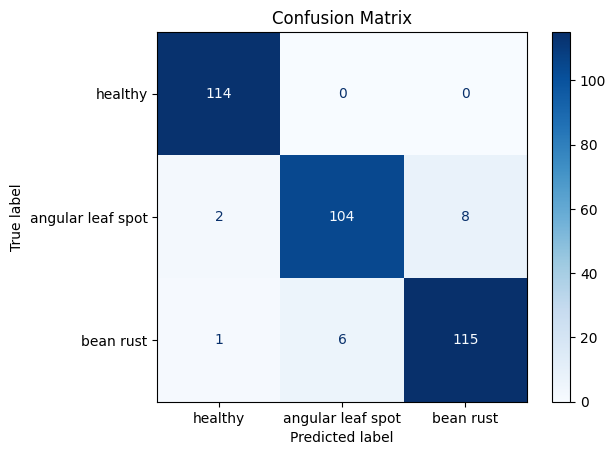

In [ ]:
class_names = ["healthy", "angular leaf spot", "bean rust"]
plot_confusion_matrix(googlenet_model, test_loader, class_names)

In [ ]:
def predict_image(model, img_path, transform, class_names):
    model.eval()
    img = Image.open(img_path).convert("RGB")
    if transform:
        img = transform(img)
    img = img.unsqueeze(0).to(device)  # Add batch dimension

    with torch.no_grad():
        output = model(img)
        pred_class = output.argmax(1).item()

    return class_names[pred_class]


Number of images found: 1034
Randomly selected image: /content/bean-leaf-lesions-classification/train/bean_rust/bean_rust_train.199.jpg
Predicted class: bean rust


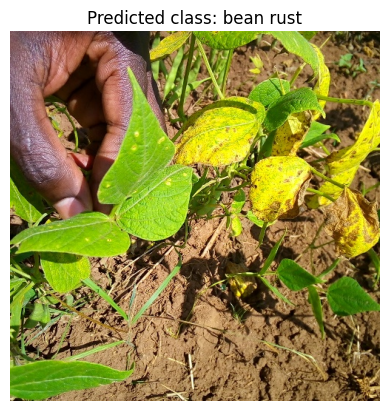

In [ ]:
train_image_paths = glob.glob("/home/dell/Desktop/project /archive(1)/train/**/*.jpg", recursive=True)
print("Number of images found:", len(train_image_paths))

# ===== Step 2: Pick a random image =====
img_path = random.choice(train_image_paths)
print("Randomly selected image:", img_path)

# ===== Step 3: Predict class using your existing function =====
predicted_class = predict_image(googlenet_model, img_path, test_transform, class_names)
print("Predicted class:", predicted_class)

# ===== Step 4: Display the image with predicted class =====
img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted class: {predicted_class}")
plt.show()